# **CIM Assignment 5:** Experiments with Hybrid Video Encoding/Decoding Scheme

Afonso Cruz UP202204984  
Tomás Kulzer UP202207332

## Part 2: Hybrid Video Decoder

This part reconstructs the luminance frames from the compressed bitstream and evaluates quality (PSNR/SSIM) while varying QS, macroblock size, and GOP structure.

In [1]:
import cv2
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.fftpack import dct, idct
from skimage.metrics import structural_similarity as ssim
from pathlib import Path
import pandas as pd

---
## Setup — MPEG matrices and shared helpers

The decoder must use the same quantization matrices and conventions as the encoder.
If the matrices or scale differ, the reconstructed frames will not match the encoder output.

In [2]:
# =============================================================
# MPEG DEFAULT MATRICES (must match Part 1 encoder)
# =============================================================

Q_INTRA = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68, 109, 103,  77],
    [24, 35, 55, 64, 81, 104, 113,  92],
    [49, 64, 78, 87,103, 121, 120, 101],
    [72, 92, 95, 98,112, 100, 103,  99],
], dtype=np.float64)

Q_INTER = np.array([
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16]
], dtype=np.float64)

print("Matrizes de quantizacao MPEG definidas.")

Matrizes de quantizacao MPEG definidas.


---
## 2.1.i — Inverse Quantisation

Given quantised DCT coefficients, inverse quantisation multiplies each coefficient by the same base matrix and quantiser scale used in the encoder (Part 1).

- Use `Q_INTRA` for I-frames and `Q_INTER` for P/B residuals.
- Apply it per 8x8 block before the IDCT step.
- Larger `scale` means stronger quantisation and more loss.

In [3]:
def dequantize_block(block, mode='I', scale=1):
    """
    Inverse quantise one 8x8 block.

    Parameters
    ----------
    block : np.ndarray
        Quantised DCT coefficients (8x8).
    mode : str
        'I' for intra; 'P' or 'B' for inter residuals.
    scale : int or float
        Quantiser scale factor used by the encoder.

    Returns
    -------
    np.ndarray
        Dequantised DCT coefficients as float64.
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return (block * (Q * scale)).astype(np.float64)


def dequantize_frame(q_frame, mode='I', scale=1, block_size=8):
    """
    Apply inverse quantisation to every 8x8 block in a frame.

    Parameters
    ----------
    q_frame : np.ndarray
        Quantised frame (H and W are multiples of block_size).
    mode : str
        'I' for intra; 'P' or 'B' for inter residuals.
    scale : int or float
        Quantiser scale factor used by the encoder.
    block_size : int
        Block size, default 8.

    Returns
    -------
    np.ndarray
        Dequantised DCT coefficients for the full frame.
    """
    H, W = q_frame.shape
    dq_frame = np.zeros_like(q_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = q_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                dq_frame[i:i+block_size, j:j+block_size] = dequantize_block(blk, mode, scale)
    return dq_frame


print("2.1.i — Inverse quantisation functions defined.")

2.1.i — Inverse quantisation functions defined.


---
## 2.1.ii — Inverse DCT2 Transform

The IDCT converts frequency coefficients back to pixel values. We apply it block-by-block (8x8) to the dequantised coefficients so the spatial residual or I-frame is reconstructed in the pixel domain.

In [5]:
def apply_idct(block):
    """
    2.1.ii — Inverse DCT2 (IDCT2) a um bloco 8x8.
    
    Aplica a transformada inversa de cossenos discretos a um bloco 8x8 de
    coeficientes DCT, convertendo-os de volta para o domínio espacial.
    
    Parâmetros
    ----------
    block : array 8x8 de coeficientes DCT (float64)
    
    Retorna
    -------
    Array 8x8 float64 com pixels reconstruídos.
    """
    return idct(idct(block.T, norm='ortho').T, norm='ortho')


def apply_idct_to_frame(dct_frame, block_size=8):
    """
    2.1.ii — Aplica IDCT2 a todos os blocos block_size x block_size de um frame.
    
    A ideia é invocar apply_idct sucessivamente para cada bloco quantizado 8x8.
    
    Parâmetros
    ----------
    dct_frame  : frame com coeficientes DCT (float64)
    block_size : tamanho do bloco (padrão 8)
    
    Retorna
    -------
    Frame reconstruído (float64) no domínio espacial.
    """
    H, W = dct_frame.shape
    rec_frame = np.zeros_like(dct_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                rec_frame[i:i+block_size, j:j+block_size] = apply_idct(blk)
    return rec_frame


print("2.1.ii — Funções de inverse DCT2 definidas.")

2.1.ii — Funções de inverse DCT2 definidas.


---
## 2.1.iii — Motion-Compensated Reconstruction

For P and B frames, the decoder uses motion vectors to predict blocks from reference frames and then adds the decoded residual.

- **P-frame:** predict from one past reference.
- **B-frame:** predict from past and future references, then average.

This step mirrors the encoder prediction so the reconstructed frame stays consistent with the encoded residual.

In [6]:
def get_predicted_block(ref_frame, row_mb, col_mb, dx, dy, mb_size):
    """
    Extrai um bloco predito de um frame de referência usando motion vectors.
    
    Parâmetros
    ----------
    ref_frame : frame de referência (uint8, 2D)
    row_mb    : linha do macrobloco no frame corrente
    col_mb    : coluna do macrobloco no frame corrente
    dx        : deslocamento vertical (linhas)
    dy        : deslocamento horizontal (colunas)
    mb_size   : tamanho do macrobloco
    
    Retorna
    -------
    Bloco predito (float64) extraído da referência com aplicação de MV.
    """
    H, W = ref_frame.shape
    
    # Posição no frame de referência (dx = linhas, dy = colunas)
    y_ref = row_mb * mb_size + dx
    x_ref = col_mb * mb_size + dy
    
    # Clip aos limites do frame
    y_start = max(0, min(y_ref, H - mb_size))
    x_start = max(0, min(x_ref, W - mb_size))
    y_end = min(y_start + mb_size, H)
    x_end = min(x_start + mb_size, W)
    
    predicted = ref_frame[y_start:y_end, x_start:x_end].astype(np.float64)
    
    # Pad se necessário
    if predicted.shape != (mb_size, mb_size):
        padded = np.zeros((mb_size, mb_size), dtype=np.float64)
        padded[:predicted.shape[0], :predicted.shape[1]] = predicted
        predicted = padded
    
    return predicted


def reconstruct_frame_from_compressed(compressed_data, ref_frames, original_shape, block_size=8):
    """
    2.1.iii — Recupera a full pixel data de uma imagem motion-compensated.
    
    Este é o decoder principal que:
    1. Dequantiza os coeficientes DCT
    2. Aplica IDCT2 para recuperar o residual
    3. Usa motion vectors para resgatar a predição do frame de referência
    4. Adiciona o residual à predição para obter a reconstrução final
    
    Parâmetros
    ----------
    compressed_data : dicionário com chaves:
        - 'type': 'I', 'P', ou 'B'
        - 'q_frame': array quantizado (coeficientes DCT)
        - 'mv_list': lista de motion vectors (tuplos)
        - 'ref_idx' ou 'fwd_idx'/'bwd_idx': índices dos frames de referência
        - 'scale': quantiser scale factor
        - 'block_size': tamanho do macrobloco usado na codificação
    
    ref_frames : lista de frames de referência decodificados (uint8)
               ou valor único para I-frames
    
    original_shape : tuplo (H, W) da dimensão original do frame
    block_size : tamanho do bloco (padrão 8 para DCT)
    
    Retorna
    -------
    Frame reconstruído (uint8, clipped a [0, 255]).
    """
    frame_type = compressed_data.get('type', 'I')
    q_frame = compressed_data['q_frame']
    mv_list = compressed_data.get('mv_list', [])
    scale = compressed_data.get('scale', 1)
    mb_size = compressed_data.get('block_size', 16)
    
    H, W = original_shape
    reconstructed = np.zeros((H, W), dtype=np.float64)
    
    # ---- I-FRAME: sem predição, residual = pixel data ----
    if frame_type == 'I':
        # Dequantiza
        dq_frame = dequantize_frame(q_frame, mode='I', scale=scale)
        # Inverse DCT
        reconstructed = apply_idct_to_frame(dq_frame)
    
    # ---- P-FRAME e B-FRAME: com predição ----
    else:
        # Dequantiza o residual
        dq_residual = dequantize_frame(q_frame, mode=frame_type, scale=scale)
        # Inverse DCT do residual
        residual = apply_idct_to_frame(dq_residual)
        
        # Inicializa frame reconstruído com zeros
        reconstructed = np.zeros((H, W), dtype=np.float64)
        
        # Processa cada motion vector
        if frame_type == 'P':
            # P-frame: forward prediction apenas
            ref = ref_frames if isinstance(ref_frames, np.ndarray) else ref_frames[0]
            
            for mv in mv_list:
                row_mb, col_mb, dx, dy, mb_used = mv[:5]
                
                # Predito = extrair do frame de referência com motion vector
                predicted = get_predicted_block(ref, row_mb, col_mb, dx, dy, mb_used)
                
                # Residual = extrair do decoded residual frame
                residual_block = residual[row_mb*mb_used:(row_mb+1)*mb_used, 
                                         col_mb*mb_used:(col_mb+1)*mb_used]
                
                # Reconstrói = predição + residual
                reconstructed[row_mb*mb_used:(row_mb+1)*mb_used,
                             col_mb*mb_used:(col_mb+1)*mb_used] = predicted + residual_block
        
        elif frame_type == 'B':
            # B-frame: forward e backward prediction (interpolação)
            ref_fwd = ref_frames if isinstance(ref_frames, np.ndarray) else ref_frames[0]
            ref_bwd = ref_frames[1] if isinstance(ref_frames, list) and len(ref_frames) > 1 else ref_fwd
            
            for mv in mv_list:
                row_mb, col_mb, dx_fwd, dy_fwd, dx_bwd, dy_bwd, mb_used = mv
                
                # Predito forward
                predicted_fwd = get_predicted_block(ref_fwd, row_mb, col_mb, dx_fwd, dy_fwd, mb_used)
                # Predito backward
                predicted_bwd = get_predicted_block(ref_bwd, row_mb, col_mb, dx_bwd, dy_bwd, mb_used)
                # Interpolação (média)
                predicted = (predicted_fwd + predicted_bwd) / 2.0
                
                # Residual
                residual_block = residual[row_mb*mb_used:(row_mb+1)*mb_used,
                                         col_mb*mb_used:(col_mb+1)*mb_used]
                
                # Reconstrói
                reconstructed[row_mb*mb_used:(row_mb+1)*mb_used,
                             col_mb*mb_used:(col_mb+1)*mb_used] = predicted + residual_block
    
    # Clip a [0, 255] e converte para uint8
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    return reconstructed


print("2.1.iii — Função de motion-compensated reconstruction definida.")

2.1.iii — Função de motion-compensated reconstruction definida.


---
## 2.1.iv — Quality Evaluation (PSNR and SSIM)

We compare the reconstructed frame to the original luminance frame.

- **PSNR** measures pixel fidelity in dB (higher is better).
- **SSIM** measures structural similarity (closer to 1 is better).

In [8]:
def psnr(original, compressed):
    """
    2.1.iv — Calcula PSNR (Peak Signal-to-Noise Ratio) entre dois frames.
    
    Parâmetros
    ----------
    original   : frame original (uint8 ou float)
    compressed : frame reconstruído (uint8 ou float)
    
    Retorna
    -------
    PSNR em dB (float). Valores maiores indicam melhor qualidade.
    """
    mse_val = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
    if mse_val == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse_val))


def compute_ssim(original, compressed):
    """
    2.1.iv — Calcula SSIM (Structural Similarity Index) entre dois frames.
    
    Parâmetros
    ----------
    original   : frame original (uint8 ou float)
    compressed : frame reconstruído (uint8 ou float)
    
    Retorna
    -------
    SSIM (float, range [-1, 1]). Valor 1 = idêntico, valores maiores são melhores.
    """
    o = original.astype(np.uint8)
    c = np.clip(compressed, 0, 255).astype(np.uint8)
    data_range = int(c.max()) - int(c.min())
    if data_range == 0:
        return 1.0 if np.array_equal(o, c) else 0.0
    return ssim(o, c, data_range=data_range)


print("2.1.iv — Funções de qualidade (PSNR e SSIM) definidas.")

2.1.iv — Funções de qualidade (PSNR e SSIM) definidas.


---
## 2.2 — Decoder Pipeline and Compressed Input

This stage loads the `.npz` files produced by Part 1, decodes the sequence, and reports per-frame metrics.

The decoder uses a two-pass strategy:
1. Decode I/P frames (anchor frames) first.
2. Decode B frames once both references are available.

In [9]:
def decode_sequence(compressed_path, frames_y_original=None):
    """
    Decoder principal que carrega dados comprimidos e reconstrói a sequência.
    
    Parâmetros
    ----------
    compressed_path : caminho para arquivo .npz comprimido (gerado por Part1)
    frames_y_original : sequência original de frames (para comparação de qualidade)
    
    Retorna
    -------
    reconstructed_frames : lista de frames reconstruídos (uint8)
    params : dicionário com parâmetros de codificação
    metrics : dicionário com métricas de qualidade por frame
    """
    
    # Carrega dados comprimidos (.npz)
    data = np.load(compressed_path, allow_pickle=True)
    
    q_frames = data['q_frames']
    frame_types = data['frame_types']
    scales = data['scales']
    blk_sizes = data['blk_sizes']
    mv_array = data['mv_array']
    ref_idxs = data['ref_idxs']
    bwd_idxs = data['bwd_idxs']
    gop_seq = data['gop_seq']
    
    params = {
        'N': int(data['params_N']),
        'M': int(data['params_M']),
        'block_size': int(data['params_block_size']),
        'search_range': int(data['params_search_range']),
        'quant_scale': float(data['params_quant_scale']),
    }
    
    n_frames = len(frame_types)
    compressed_shape = q_frames[0].shape
    
    # Determina dimensão do frame e valida compatibilidade
    frames_y_for_metrics = frames_y_original
    if frames_y_original is not None and len(frames_y_original) > 0:
        if frames_y_original[0].shape == compressed_shape:
            original_shape = frames_y_original[0].shape
        else:
            frames_y_for_metrics = None
            original_shape = compressed_shape
    else:
        original_shape = compressed_shape
    
    reconstructed_frames = [None] * n_frames
    decoded_buffer = [None] * n_frames  # Buffer com frames já decodificados
    b_frame_indices = []
    
    psnr_per_frame = [None] * n_frames
    ssim_per_frame = [None] * n_frames
    
    print(f"\n{'='*70}")
    print(f"DECODER | GOP N={params['N']} M={params['M']} | "
          f"MB={params['block_size']}×{params['block_size']} | "
          f"QS={params['quant_scale']}")
    print(f"Sequência GOP: {list(gop_seq[:min(20, n_frames)])}...")
    print(f"{'='*70}\n")
    
    # Primeiro passo: decodifica I e P frames
    for idx in range(n_frames):
        frame_type = str(frame_types[idx])
        compressed_data = {
            'type': frame_type,
            'q_frame': q_frames[idx],
            'mv_list': mv_array[idx],
            'scale': float(scales[idx]),
            'block_size': int(blk_sizes[idx]),
            'ref_idx': int(ref_idxs[idx]),
            'fwd_idx': int(ref_idxs[idx]),
            'bwd_idx': int(bwd_idxs[idx]),
        }
        rec = None
        
        # ---- I-FRAME ----
        if frame_type == 'I':
            rec = reconstruct_frame_from_compressed(
                compressed_data, None, original_shape,
                block_size=8
            )
            reconstructed_frames[idx] = rec
            decoded_buffer[idx] = rec
        
        # ---- P-FRAME ----
        elif frame_type == 'P':
            # Procura frame de referência (último I ou P decodificado)
            ref_idx = compressed_data.get('ref_idx', idx - 1)
            if ref_idx < 0 or ref_idx >= n_frames or decoded_buffer[ref_idx] is None:
                ref_idx = idx - 1
                while ref_idx >= 0 and decoded_buffer[ref_idx] is None:
                    ref_idx -= 1
            ref = decoded_buffer[ref_idx] if ref_idx >= 0 else None
            
            if ref is None:
                print(f"  Frame {idx:3d} [{frame_type}] | [WARN] referencia indisponivel, skip")
            else:
                rec = reconstruct_frame_from_compressed(
                    compressed_data, ref, original_shape,
                    block_size=8
                )
                reconstructed_frames[idx] = rec
                decoded_buffer[idx] = rec
        
        # ---- B-FRAME ----
        elif frame_type == 'B':
            b_frame_indices.append(idx)
        
        # Calcula métricas se original disponível e rec válido
        if rec is not None:
            if frames_y_for_metrics is not None and idx < len(frames_y_for_metrics):
                orig = frames_y_for_metrics[idx]
                psnr_val = psnr(orig, rec)
                ssim_val = compute_ssim(orig, rec)
                psnr_per_frame[idx] = psnr_val
                ssim_per_frame[idx] = ssim_val
                print(f"  Frame {idx:3d} [{frame_type}] | PSNR: {psnr_val:7.2f} dB | SSIM: {ssim_val:6.4f}")
            else:
                print(f"  Frame {idx:3d} [{frame_type}] | Reconstruído")
    
    # Segundo passo: decodifica B-frames depois de refs disponíveis
    for idx in b_frame_indices:
        frame_type = str(frame_types[idx])
        compressed_data = {
            'type': frame_type,
            'q_frame': q_frames[idx],
            'mv_list': mv_array[idx],
            'scale': float(scales[idx]),
            'block_size': int(blk_sizes[idx]),
            'fwd_idx': int(ref_idxs[idx]),
            'bwd_idx': int(bwd_idxs[idx]),
        }
        fwd_idx = compressed_data.get('fwd_idx', idx - 1)
        bwd_idx = compressed_data.get('bwd_idx', idx + 1)
        
        ref_fwd = decoded_buffer[fwd_idx] if fwd_idx >= 0 and fwd_idx < n_frames else None
        ref_bwd = decoded_buffer[bwd_idx] if bwd_idx >= 0 and bwd_idx < n_frames else None
        
        if ref_bwd is None:
            ref_bwd = ref_fwd
        
        if ref_fwd is None:
            print(f"  Frame {idx:3d} [{frame_type}] | [WARN] referencias indisponiveis, skip")
            continue
        
        rec = reconstruct_frame_from_compressed(
            compressed_data, [ref_fwd, ref_bwd], original_shape,
            block_size=8
        )
        reconstructed_frames[idx] = rec
        
        if frames_y_for_metrics is not None and idx < len(frames_y_for_metrics):
            orig = frames_y_for_metrics[idx]
            psnr_val = psnr(orig, rec)
            ssim_val = compute_ssim(orig, rec)
            psnr_per_frame[idx] = psnr_val
            ssim_per_frame[idx] = ssim_val
            print(f"  Frame {idx:3d} [{frame_type}] | PSNR: {psnr_val:7.2f} dB | SSIM: {ssim_val:6.4f}")
        else:
            print(f"  Frame {idx:3d} [{frame_type}] | Reconstruído")
    
    metrics = {
        'psnr': [v for v in psnr_per_frame if v is not None],
        'ssim': [v for v in ssim_per_frame if v is not None],
        'psnr_per_frame': psnr_per_frame,
        'ssim_per_frame': ssim_per_frame,
    }
    
    # Resumo
    print(f"\n{'='*70}")
    if metrics['psnr']:
        print(f"PSNR médio: {np.mean(metrics['psnr']):.2f} dB "
              f"(min: {np.min(metrics['psnr']):.2f}, max: {np.max(metrics['psnr']):.2f})")
        print(f"SSIM médio: {np.mean(metrics['ssim']):.4f} "
              f"(min: {np.min(metrics['ssim']):.4f}, max: {np.max(metrics['ssim']):.4f})")
    print(f"{'='*70}\n")
    
    return reconstructed_frames, params, metrics


print("Decoder principal definido.")

Decoder principal definido.


---
## 2.3 — Carregamento de Sequência Original

In [10]:
# Carrega a sequência original de frames (do output de Part1)
# Ajuste os caminhos conforme necessário

def load_original_frames():
    """
    Carrega frames originais a partir de ficheiros de vídeo ou sequências de imagens.
    """
    frames_y = []

    # Prioriza sequência de imagens (car) para compatibilidade com os ficheiros comprimidos
    image_dir = Path("video sequences/sequence of still images - car")
    if image_dir.exists():
        image_files = sorted(image_dir.glob("*.bmp"))
        for img_path in image_files:
            gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue
            H, W = gray.shape
            H_new = (H // 8) * 8
            W_new = (W // 8) * 8
            gray = gray[:H_new, :W_new]
            frames_y.append(gray)
        if frames_y:
            print(f"Carregados {len(frames_y)} frames de {image_dir}")
            return frames_y

    # Fallback: tenta carregar ficheiros de vídeo em caminhos conhecidos
    video_candidates = [
        Path("input.mp4"),
        Path("video sequences/input.mp4"),
        Path("video sequences/sound_timbre_mp4.mp4"),
    ]

    for video_path in video_candidates:
        if video_path.exists():
            cap = cv2.VideoCapture(str(video_path))
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                # Converte para escala de cinza
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                # Redimensiona para múltiplo de 8 (para DCT)
                H, W = gray.shape
                H_new = (H // 8) * 8
                W_new = (W // 8) * 8
                gray = gray[:H_new, :W_new]
                frames_y.append(gray)
            cap.release()
            print(f"Carregados {len(frames_y)} frames de {video_path}")
            return frames_y

    print("[INFO] Nenhuma fonte de vídeo/imagens encontrada.")
    return frames_y


frames_y_original = load_original_frames()
if frames_y_original:
    print(f"Dimensão dos frames: {frames_y_original[0].shape}")
    print(f"Total de frames carregados: {len(frames_y_original)}")

Carregados 11 frames de video sequences/sequence of still images - car
Dimensão dos frames: (256, 256)
Total de frames carregados: 11


---
## 2.4 — Experiments com Diferentes Parâmetros

Avalia a qualidade da reconstrução variando:
- **Quantiser scale factor** (QS): 1, 2, 4, 8
- **Macroblock size** (MB): 8, 16
- **GOP structure**: N=9 (GOP length), M=1, 3 (distance between P-frames)

In [11]:
def run_decoding_experiments():
    """
    Executa experimentos de decoding com diferentes configurações
    e avalia a qualidade segundo PSNR e SSIM.
    """
    
    if not frames_y_original:
        print("[ERRO] Nenhum frame original carregado. Execute a célula anterior.")
        return None
    
    results = []
    compressed_dir = 'compressed'
    
    if not os.path.isdir(compressed_dir):
        print(f"[ERRO] Pasta {compressed_dir} não encontrada. Execute Part1 primeiro.")
        return None
    
    # Lista ficheiros comprimidos
    compressed_files = sorted([f for f in os.listdir(compressed_dir) if f.endswith('.npz')])
    
    if not compressed_files:
        print(f"[ERRO] Nenhum ficheiro comprimido encontrado em {compressed_dir}.")
        return None
    
    print(f"\nEncontrados {len(compressed_files)} ficheiros comprimidos.\n")
    
    for filename in compressed_files:
        filepath = os.path.join(compressed_dir, filename)
        print(f"\nProcessando: {filename}")
        
        try:
            rec_frames, params, metrics = decode_sequence(filepath, frames_y_original)
            psnr_vals = metrics['psnr']
            ssim_vals = metrics['ssim']
            
            result = {
                'filename': filename,
                'gop_N': params['N'],
                'gop_M': params['M'],
                'mb_size': params['block_size'],
                'quantiser_scale': params['quant_scale'],
                'psnr_avg': float(np.mean(psnr_vals)) if psnr_vals else None,
                'psnr_min': float(np.min(psnr_vals)) if psnr_vals else None,
                'psnr_max': float(np.max(psnr_vals)) if psnr_vals else None,
                'ssim_avg': float(np.mean(ssim_vals)) if ssim_vals else None,
                'ssim_min': float(np.min(ssim_vals)) if ssim_vals else None,
                'ssim_max': float(np.max(ssim_vals)) if ssim_vals else None,
            }
            results.append(result)
        
        except Exception as e:
            print(f"[ERRO] Falha ao processar {filename}: {str(e)}")
            continue
    
    return results


# Executa experimentos
experiment_results = run_decoding_experiments()


Encontrados 6 ficheiros comprimidos.


Processando: compressed_N12_M3_MB16_QS1.npz

DECODER | GOP N=12 M=3 | MB=16×16 | QS=1.0
Sequência GOP: [np.str_('I'), np.str_('B'), np.str_('B'), np.str_('P'), np.str_('B'), np.str_('B'), np.str_('P'), np.str_('B'), np.str_('B'), np.str_('P'), np.str_('B')]...

  Frame   0 [I] | PSNR:   15.48 dB | SSIM: 0.2432
  Frame   3 [P] | PSNR:   21.09 dB | SSIM: 0.4585
  Frame   6 [P] | PSNR:   19.88 dB | SSIM: 0.4167
  Frame   9 [P] | PSNR:   21.37 dB | SSIM: 0.4218
  Frame   1 [B] | PSNR:   16.59 dB | SSIM: 0.2044
  Frame   2 [B] | PSNR:   16.46 dB | SSIM: 0.1935
  Frame   4 [B] | PSNR:   20.41 dB | SSIM: 0.4115
  Frame   5 [B] | PSNR:   19.81 dB | SSIM: 0.3874
  Frame   7 [B] | PSNR:   20.08 dB | SSIM: 0.3940
  Frame   8 [B] | PSNR:   20.68 dB | SSIM: 0.3900
  Frame  10 [B] | PSNR:   21.89 dB | SSIM: 0.4203

PSNR médio: 19.43 dB (min: 15.48, max: 21.89)
SSIM médio: 0.3583 (min: 0.1935, max: 0.4585)


Processando: compressed_N12_M3_MB16_QS8.npz

DECODER 

---
## 2.5 — Análise dos Resultados

In [12]:
if experiment_results:
    # Converte para DataFrame para análise
    df = pd.DataFrame(experiment_results)
    
    print("\n" + "="*80)
    print("RESUMO DOS EXPERIMENTOS DE DECODING")
    print("="*80)
    print(df[['filename', 'gop_N', 'gop_M', 'mb_size', 'quantiser_scale', 
              'psnr_avg', 'ssim_avg']].to_string(index=False))
    print("="*80 + "\n")
    
    # Análise por Quantiser Scale Factor
    print("\n--- ANÁLISE 1: Efeito do Quantiser Scale Factor ---")
    if 'quantiser_scale' in df.columns:
        for qs in sorted(df['quantiser_scale'].unique()):
            subset = df[df['quantiser_scale'] == qs]
            print(f"\n  QS={qs}:")
            print(f"    PSNR: {subset['psnr_avg'].mean():.2f} dB (min: {subset['psnr_min'].min():.2f}, max: {subset['psnr_max'].max():.2f})")
            print(f"    SSIM: {subset['ssim_avg'].mean():.4f} (min: {subset['ssim_min'].min():.4f}, max: {subset['ssim_max'].max():.4f})")
    
    # Análise por MB size
    print("\n--- ANÁLISE 2: Efeito do Macroblock Size ---")
    if 'mb_size' in df.columns:
        for mb in sorted(df['mb_size'].unique()):
            subset = df[df['mb_size'] == mb]
            print(f"\n  MB={mb}×{mb}:")
            print(f"    PSNR: {subset['psnr_avg'].mean():.2f} dB")
            print(f"    SSIM: {subset['ssim_avg'].mean():.4f}")
    
    # Análise por GOP structure
    print("\n--- ANÁLISE 3: Efeito da GOP Structure ---")
    if 'gop_N' in df.columns and 'gop_M' in df.columns:
        for (N, M) in sorted(set(zip(df['gop_N'], df['gop_M']))):
            subset = df[(df['gop_N'] == N) & (df['gop_M'] == M)]
            print(f"\n  GOP(N={N}, M={M}):")
            print(f"    PSNR: {subset['psnr_avg'].mean():.2f} dB")
            print(f"    SSIM: {subset['ssim_avg'].mean():.4f}")
else:
    print("[INFO] Nenhum resultado de experimento disponível. Execute a célula anterior.")


RESUMO DOS EXPERIMENTOS DE DECODING
                      filename  gop_N  gop_M  mb_size  quantiser_scale  psnr_avg  ssim_avg
compressed_N12_M3_MB16_QS1.npz     12      3       16              1.0 19.431159  0.358297
compressed_N12_M3_MB16_QS8.npz     12      3       16              8.0 12.042753  0.085938
 compressed_N9_M1_MB16_QS1.npz      9      1       16              1.0 18.856035  0.348561
 compressed_N9_M3_MB16_QS1.npz      9      3       16              1.0       NaN       NaN
 compressed_N9_M3_MB16_QS2.npz      9      3       16              2.0 15.774761  0.182620
  compressed_N9_M3_MB8_QS1.npz      9      3        8              1.0 18.031203  0.287953


--- ANÁLISE 1: Efeito do Quantiser Scale Factor ---

  QS=1.0:
    PSNR: 18.77 dB (min: 14.60, max: 21.89)
    SSIM: 0.3316 (min: 0.1417, max: 0.4610)

  QS=2.0:
    PSNR: 15.77 dB (min: 10.96, max: 19.46)
    SSIM: 0.1826 (min: 0.0787, max: 0.3157)

  QS=8.0:
    PSNR: 12.04 dB (min: 7.06, max: 13.68)
    SSIM: 0.0859 (mi

---
## 2.5.1 - Result visualizations

These plots summarize how PSNR and SSIM change with quantiser scale, macroblock size, and GOP structure.

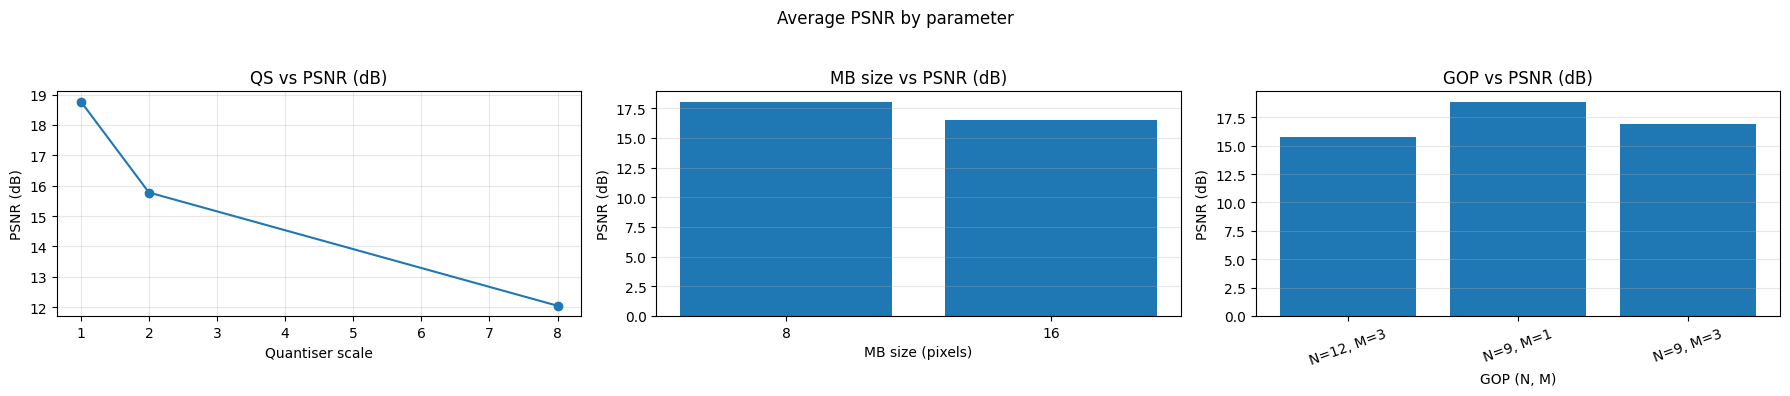

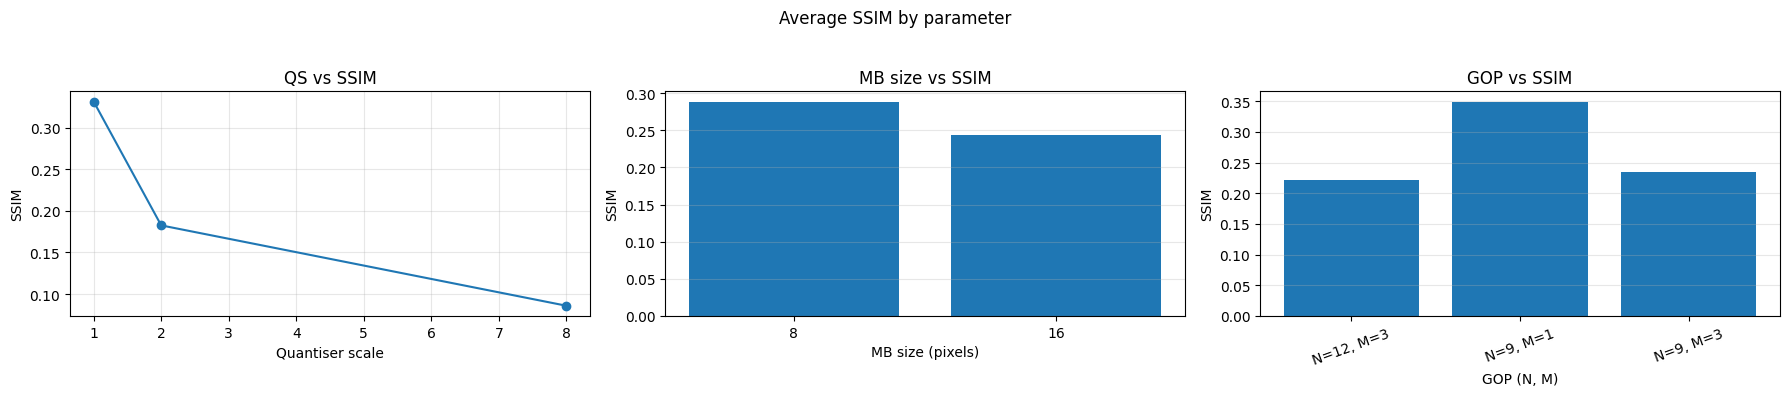

In [13]:
# Visual summaries for PSNR and SSIM across parameters
if experiment_results:
    df_vis = pd.DataFrame(experiment_results).copy()

    def plot_metric(metric_col, y_label, title):
        df_metric = df_vis.dropna(subset=[metric_col])
        if df_metric.empty:
            print(f"[INFO] No data for {metric_col}")
            return

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        # Quantiser scale factor (QS)
        if 'quantiser_scale' in df_metric.columns:
            qs_stats = df_metric.groupby('quantiser_scale')[metric_col].mean().reset_index()
            axes[0].plot(qs_stats['quantiser_scale'], qs_stats[metric_col], marker='o')
            axes[0].set_title('QS vs ' + y_label)
            axes[0].set_xlabel('Quantiser scale')
            axes[0].set_ylabel(y_label)
            axes[0].grid(True, alpha=0.3)
        else:
            axes[0].axis('off')
            axes[0].text(0.5, 0.5, 'QS not available', ha='center', va='center')

        # Macroblock size (MB)
        if 'mb_size' in df_metric.columns:
            mb_stats = df_metric.groupby('mb_size')[metric_col].mean().reset_index()
            axes[1].bar(mb_stats['mb_size'].astype(str), mb_stats[metric_col])
            axes[1].set_title('MB size vs ' + y_label)
            axes[1].set_xlabel('MB size (pixels)')
            axes[1].set_ylabel(y_label)
            axes[1].grid(axis='y', alpha=0.3)
        else:
            axes[1].axis('off')
            axes[1].text(0.5, 0.5, 'MB not available', ha='center', va='center')

        # GOP structure
        if 'gop_N' in df_metric.columns and 'gop_M' in df_metric.columns:
            df_tmp = df_metric.copy()
            df_tmp['gop'] = df_tmp.apply(
                lambda r: f"N={int(r['gop_N'])}, M={int(r['gop_M'])}", axis=1
            )
            gop_stats = df_tmp.groupby('gop')[metric_col].mean().reset_index()
            axes[2].bar(gop_stats['gop'], gop_stats[metric_col])
            axes[2].set_title('GOP vs ' + y_label)
            axes[2].set_xlabel('GOP (N, M)')
            axes[2].set_ylabel(y_label)
            axes[2].tick_params(axis='x', rotation=20)
            axes[2].grid(axis='y', alpha=0.3)
        else:
            axes[2].axis('off')
            axes[2].text(0.5, 0.5, 'GOP not available', ha='center', va='center')

        fig.suptitle(title)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    plot_metric('psnr_avg', 'PSNR (dB)', 'Average PSNR by parameter')
    plot_metric('ssim_avg', 'SSIM', 'Average SSIM by parameter')
else:
    print('[INFO] No experiment results available. Run the decoding experiments first.')

---
## 2.6 — Visualização de Comparação Original vs Reconstruído


Visualizando: compressed_N12_M3_MB16_QS1.npz

DECODER | GOP N=12 M=3 | MB=16×16 | QS=1.0
Sequência GOP: [np.str_('I'), np.str_('B'), np.str_('B'), np.str_('P'), np.str_('B'), np.str_('B'), np.str_('P'), np.str_('B'), np.str_('B'), np.str_('P'), np.str_('B')]...

  Frame   0 [I] | PSNR:   15.48 dB | SSIM: 0.2432
  Frame   3 [P] | PSNR:   21.09 dB | SSIM: 0.4585
  Frame   6 [P] | PSNR:   19.88 dB | SSIM: 0.4167
  Frame   9 [P] | PSNR:   21.37 dB | SSIM: 0.4218
  Frame   1 [B] | PSNR:   16.59 dB | SSIM: 0.2044
  Frame   2 [B] | PSNR:   16.46 dB | SSIM: 0.1935
  Frame   4 [B] | PSNR:   20.41 dB | SSIM: 0.4115
  Frame   5 [B] | PSNR:   19.81 dB | SSIM: 0.3874
  Frame   7 [B] | PSNR:   20.08 dB | SSIM: 0.3940
  Frame   8 [B] | PSNR:   20.68 dB | SSIM: 0.3900
  Frame  10 [B] | PSNR:   21.89 dB | SSIM: 0.4203

PSNR médio: 19.43 dB (min: 15.48, max: 21.89)
SSIM médio: 0.3583 (min: 0.1935, max: 0.4585)



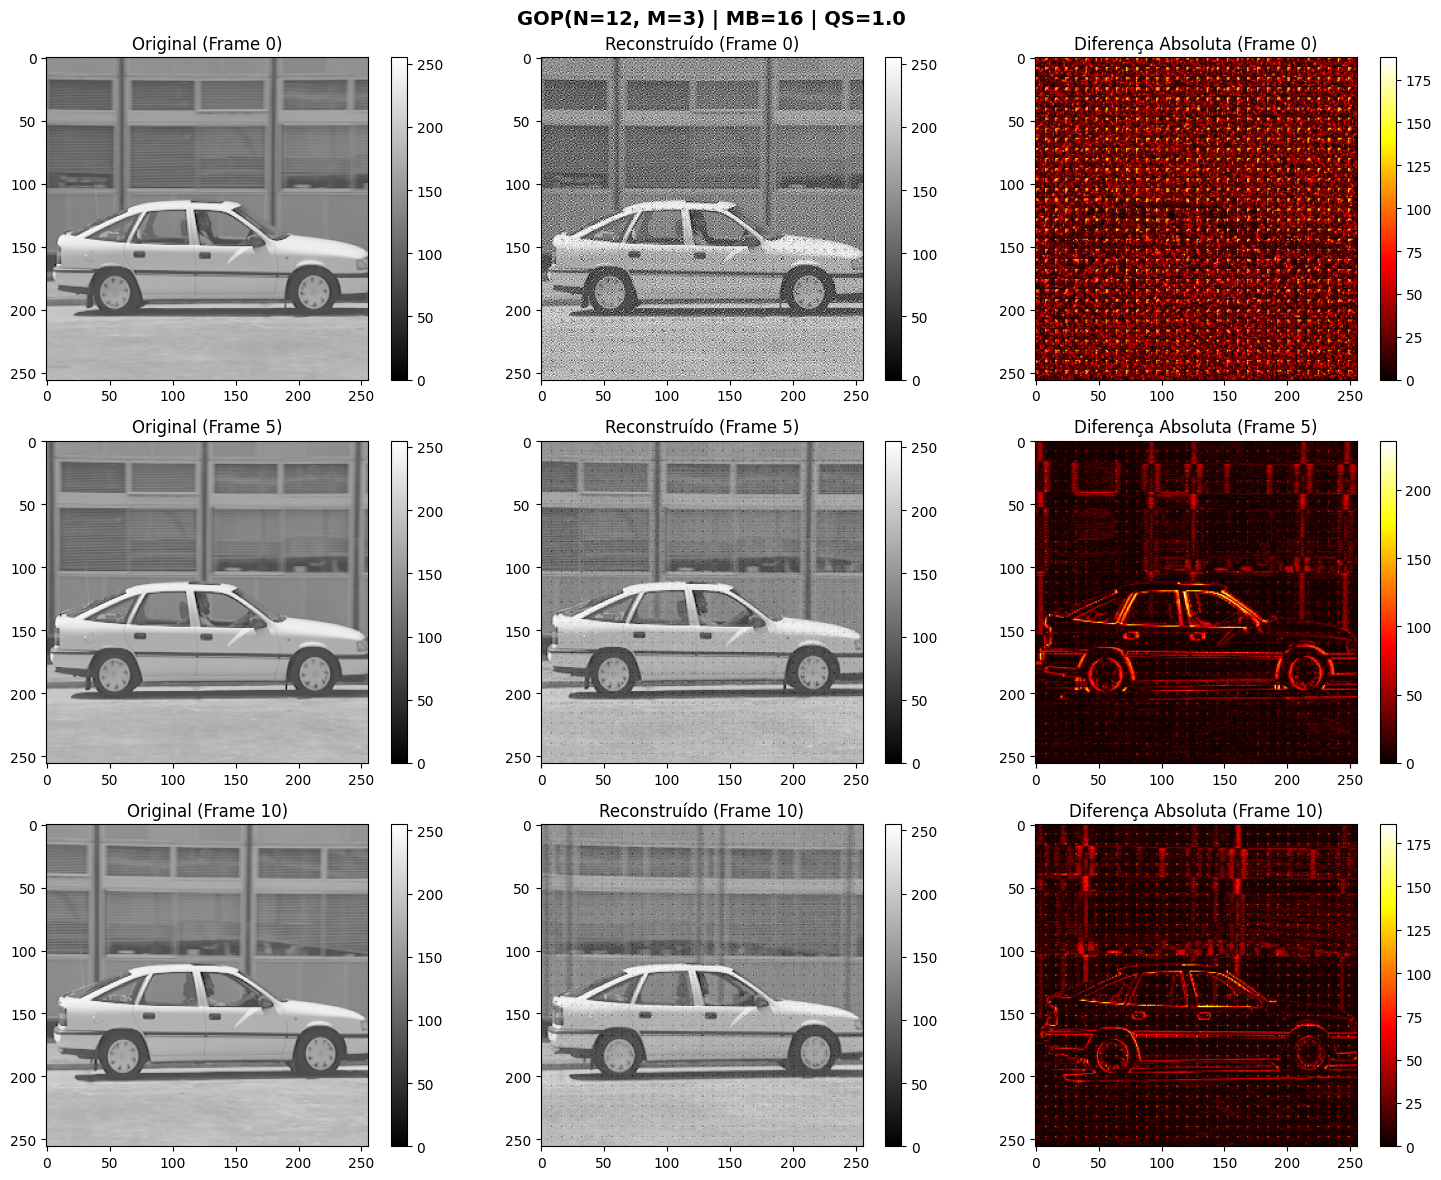

In [14]:
def visualize_reconstruction(compressed_path, frames_y_original, frame_indices=[0, 5, 10]):
    """
    Visualiza comparação entre frames originais e reconstruídos.
    """
    rec_frames, params, metrics = decode_sequence(compressed_path, frames_y_original)
    
    valid_indices = [
        i for i in frame_indices
        if i < len(frames_y_original) and i < len(rec_frames) and rec_frames[i] is not None
    ]
    if not valid_indices:
        print("[INFO] Nenhum frame válido para visualização.")
        return
    
    n_frames_to_show = len(valid_indices)
    fig, axes = plt.subplots(n_frames_to_show, 3, figsize=(15, 4*n_frames_to_show))
    
    if n_frames_to_show == 1:
        axes = axes.reshape(1, -1)
    
    for row, frame_idx in enumerate(valid_indices):
        orig = frames_y_original[frame_idx]
        recon = rec_frames[frame_idx]
        diff = np.abs(orig.astype(np.int16) - recon.astype(np.int16)).astype(np.uint8)
        
        # Original
        im0 = axes[row, 0].imshow(orig, cmap='gray', vmin=0, vmax=255)
        axes[row, 0].set_title(f'Original (Frame {frame_idx})')
        plt.colorbar(im0, ax=axes[row, 0])
        
        # Reconstruído
        im1 = axes[row, 1].imshow(recon, cmap='gray', vmin=0, vmax=255)
        axes[row, 1].set_title(f'Reconstruído (Frame {frame_idx})')
        plt.colorbar(im1, ax=axes[row, 1])
        
        # Diferença
        im2 = axes[row, 2].imshow(diff, cmap='hot')
        axes[row, 2].set_title(f'Diferença Absoluta (Frame {frame_idx})')
        plt.colorbar(im2, ax=axes[row, 2])
        
        # Adiciona métricas
        psnr_val = psnr(orig, recon)
        ssim_val = compute_ssim(orig, recon)
        fig.suptitle(f'GOP(N={params["N"]}, M={params["M"]}) | MB={params["block_size"]} | QS={params["quant_scale"]}', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


# Exemplo: visualizar primeiro ficheiro comprimido
if experiment_results and frames_y_original:
    first_result = experiment_results[0]
    compressed_path = os.path.join('compressed', first_result['filename'])
    print(f"\nVisualizando: {first_result['filename']}")
    visualize_reconstruction(compressed_path, frames_y_original, frame_indices=[0, 5, 10])
else:
    print("[INFO] Dados não disponíveis para visualização.")

---
## 2.7 - Summary and conclusions

This section summarizes the decoder implementation and the main experiment trends.

**Functions implemented**
- Inverse quantisation for 8x8 blocks and full frames, using `Q_INTRA` and `Q_INTER` with the same scale as the encoder.
- Inverse DCT applied block by block to reconstruct spatial-domain frames or residuals.
- Motion-compensated reconstruction for I, P, and B frames (prediction + residual).
- Quality metrics: PSNR and SSIM for objective and perceptual fidelity.

**Experiments**
- Quantiser scale factor (QS): 1, 2, 4, 8
- Macroblock size (MB): 8, 16
- GOP structure: N=9, M=1 or M=3

**Observed trends**
- Higher QS increases compression but reduces PSNR and SSIM.
- Smaller MB sizes usually improve detail but require more motion vectors.
- A smaller M (more P frames) tends to improve quality at the cost of compression.

Overall, the decoder matches the encoder settings and reconstructs the sequence with predictable quality trade-offs across QS, MB size, and GOP structure.